## Homework

**Please:**

1) generate random numbers following normal distributions using numbers from an uniform distribution
2) make control plots. 

**Generation:** 

Each of following steps should be implemented in **a single line of code**, three lines in total for all the steps.    
* generate nPoints $\times$ nSamples (```nPoints``` rows, ```nSamples``` columns) matrix of random numbers from uniform distribution in range [0,1].
  Use values: 
  
  ```Python
  
    nPoints = 100000
    nSamples = 120
    
  ```
* for each row sum all the columns
* subtract 0.5$\times$nSamples and divide by $\sqrt{nSamples/12}$

**Control plots:**

* plot histogram of the result on log and linear scales. Use ```bins=np.arange(-3,3,0.1)``` for the definition of bins
* overlay a line for normal distribution with proper scaling
* plot a ratio ```Histogram/Gauss```. Put attention to correct alignment between histogram and Gauss evaluation points


CPU times: user 6 µs, sys: 0 ns, total: 6 µs
Wall time: 12.4 µs


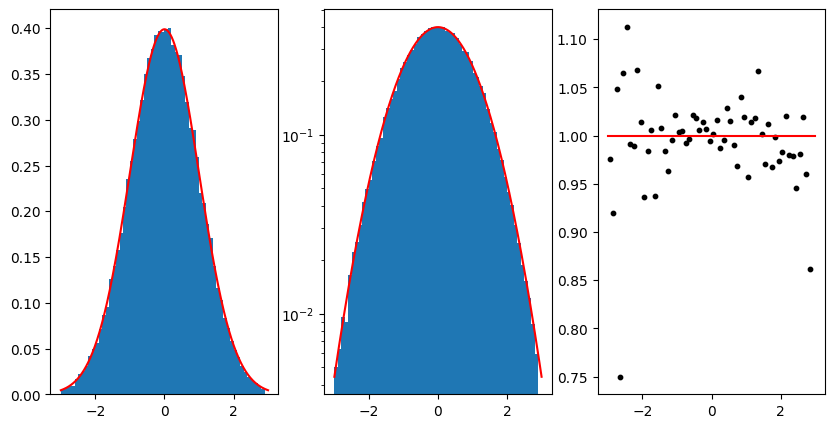

In [29]:
%time
import numpy as np
import matplotlib.pyplot as plt

nPoints = 100000
nSamples = 120

X = np.random.uniform(0, 1, (nPoints, nSamples))
X_reduced = np.sum(X, axis=1)
X_prime = (X_reduced - 0.5 * nSamples) / (np.sqrt(nSamples / 12))

bins = np.arange(-3, 3, 0.1)
X_Space = np.linspace(-3, 3, 610)
Y_Gaussian = 1/np.sqrt(2*np.pi) * np.exp(-X_Space**2 / 2)

counts, bin_edges = np.histogram(X_prime, bins=bins, density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
y_gauss_centers = (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * bin_centers**2)
ratio = counts / y_gauss_centers

fig, axes = plt.subplots(1,3, figsize=(10,5))
axes[0].hist(X_prime, bins=bins, density=True)
axes[0].plot(X_Space, Y_Gaussian, color='red')
axes[1].hist(X_prime, bins=bins, density=True, log=True)
axes[1].plot(X_Space, Y_Gaussian, color='red')
axes[2].scatter(bin_centers, ratio, color='black', s=10)
axes[2].plot(X_Space, np.ones_like(X_Space), color='red')

